# Customer Segmentation Using Unsupervised Learning

## Introduction

Customer segmentation is a data-driven technique used to group customers with similar characteristics and purchasing behavior. It enables businesses to better understand their customers, create targeted marketing campaigns, improve customer satisfaction, and optimize business strategies.

In this project, customer segmentation is performed using the K-Means clustering algorithm on the Mall Customers dataset. The analysis includes exploratory data analysis (EDA), dimensionality reduction using Principal Component Analysis (PCA), cluster visualization, and marketing strategy recommendations for each customer segment.

## Problem Statement

Businesses often serve customers with different spending behaviors, income levels, and purchasing patterns. Applying the same marketing strategy to every customer may reduce marketing effectiveness and customer engagement.

To support data-driven decision-making, customers need to be segmented into meaningful groups based on their characteristics. These segments help businesses understand customer behavior and design personalized marketing strategies for different customer groups.

## Project Objectives

The main objectives of this project are:

- Perform Exploratory Data Analysis (EDA).
- Segment customers using the K-Means clustering algorithm.
- Determine the optimal number of customer clusters.
- Visualize customer segments using Principal Component Analysis (PCA).
- Analyze the characteristics of each customer segment.
- Recommend marketing strategies based on the identified customer segments.

## Dataset Information

This project uses the **Mall Customers Dataset**, which is widely used for customer segmentation and unsupervised learning tasks.

**Dataset Source:**  
https://www.kaggle.com/datasets/shwetabh123/mall-customers

The dataset contains demographic information and spending behavior of mall customers.

The primary objective of this dataset is to identify groups of customers with similar characteristics based on their demographic attributes and spending patterns.

Each record represents an individual customer and includes information such as gender, age, annual income, and spending score assigned by the shopping mall.

This dataset is well suited for clustering techniques such as **K-Means**, allowing businesses to identify distinct customer segments and develop targeted marketing strategies.

### Dataset Summary

| Attribute | Description |
|------------|-------------|
| Dataset Name | Mall Customers Dataset |
| Source | Kaggle |
| File Used | Mall_Customers.csv |
| Problem Type | Unsupervised Learning (Clustering) |
| Algorithm | K-Means Clustering |
| Domain | Retail and Marketing |

### Dataset Features

| Feature | Description |
|----------|-------------|
| CustomerID | Unique identifier for each customer |
| Gender | Customer gender (Male/Female) |
| Age | Customer age (years) |
| Annual Income (k$) | Annual income in thousand dollars |
| Spending Score (1–100) | Spending score assigned by the mall |

## Import Required Libraries

Before starting the analysis, the required Python libraries are imported.

These libraries are used for data manipulation, visualization, preprocessing, clustering, and dimensionality reduction throughout the project.

- **Pandas** and **NumPy** are used for data manipulation and numerical computations.
- **Matplotlib** and **Seaborn** are used for data visualization.
- **Scikit-learn** is used for feature scaling, K-Means clustering, and Principal Component Analysis (PCA).

In [1]:
# Data Manipulation

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing

from sklearn.preprocessing import StandardScaler

# Machine Learning

from sklearn.cluster import KMeans

# Dimensionality Reduction

from sklearn.decomposition import PCA

## Load Dataset

The Mall Customers dataset is loaded into a Pandas DataFrame for analysis.

A copy of the original dataset is also created to preserve the raw data while performing data cleaning, preprocessing, and customer segmentation.

In [2]:
# Load the dataset

df = pd.read_csv("../dataset/Mall_Customers.csv")

# Create a copy of the original dataset

df_clean = df.copy()

## Dataset Preview

After loading the dataset, the first few records are displayed to verify that the dataset has been loaded correctly and to gain an initial understanding of its structure.

In [10]:
# Display the first five records

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Cleaning and Preprocessing

Data cleaning is an essential step before performing exploratory data analysis and clustering.

In this phase, the dataset is examined for missing values, duplicate records, data types, and overall data quality to ensure it is suitable for customer segmentation.

### Dataset Shape

The shape of the dataset is examined to determine the total number of records and features available for analysis.

In [12]:
# Display dataset shape

df.shape

(200, 5)

#### Observation

The dataset contains **200 customer records** and **5 features**, providing sufficient information for customer segmentation using unsupervised learning techniques.

### Dataset Information

The dataset information is examined to understand the structure of the dataset, including column names, data types, and non-null values.

In [15]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


#### Observation

The dataset contains **200 records** and **5 features**. All columns have **200 non-null values**, indicating that there are no missing values. The dataset consists of one categorical feature and four numerical features, making it suitable for exploratory data analysis and customer segmentation.

### Duplicate Records

Duplicate records are examined to ensure that each customer is represented only once in the dataset. Removing duplicate entries helps maintain data quality and prevents biased clustering results.

In [16]:
# Check duplicate records

print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


#### Observation

No duplicate records were found in the dataset. The dataset is ready for further analysis without removing any duplicate observations.

### Descriptive Statistics

Descriptive statistics provide a statistical summary of the numerical features, including measures such as count, mean, standard deviation, minimum, maximum, and quartiles.

This summary helps understand the distribution and variation of numerical variables before performing exploratory data analysis and clustering.

In [19]:
# Display descriptive statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


#### Observation

The dataset contains **200 customer records**. The average customer age is **38.85 years**, while the average annual income is **60.56 thousand dollars**. The average spending score is **50.20**, indicating a balanced distribution of customer spending behavior. Overall, the numerical features show sufficient variation for meaningful customer segmentation.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand customer demographics and spending behavior through statistical summaries and visualizations.

The insights obtained during this phase help identify meaningful patterns in the data before applying K-Means clustering for customer segmentation.

### Gender Distribution

The distribution of customer gender is analyzed to understand the proportion of male and female customers in the dataset.

In [21]:
# Display gender distribution

df["Genre"].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

#### Gender Distribution Visualization

A count plot is used to visualize the distribution of male and female customers in the dataset.

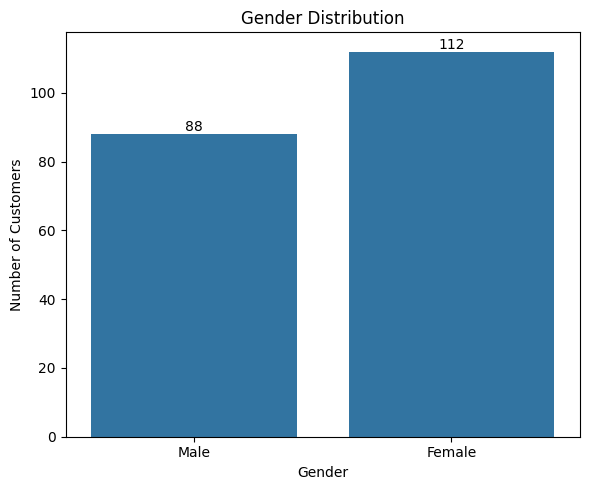

In [40]:
# Plot gender distribution

plt.figure(figsize=(6,5))

ax=sns.countplot(
    data=df,
    x="Genre",
)

# Add value labels
ax.bar_label(ax.containers[0])

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save figure
# plt.savefig(
#     "../outputs/figures/01_gender_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

##### Observation

The dataset contains **112 female customers** and **88 male customers**. Female customers slightly outnumber male customers, although the overall gender distribution is relatively balanced.

### Age Distribution

The age distribution of customers is analyzed to understand the demographic composition of the customer base and identify the most common age groups.

#### Age Distribution Histogram

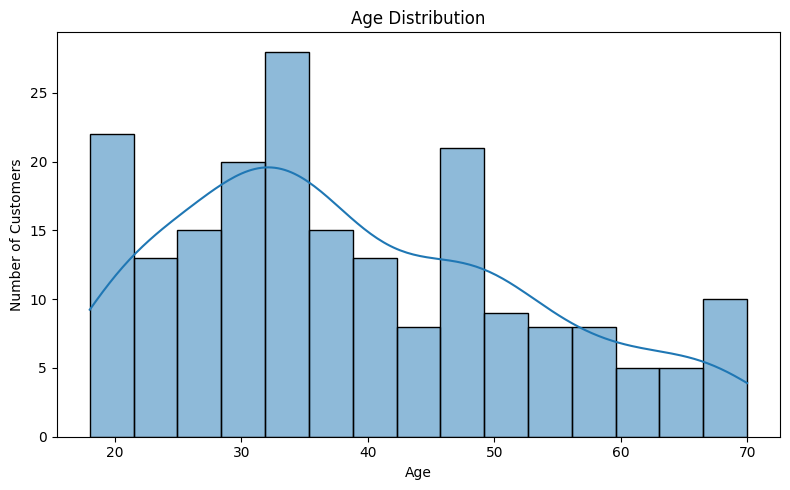

In [47]:
# Plot age distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/02_age_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Age Distribution Box Plot

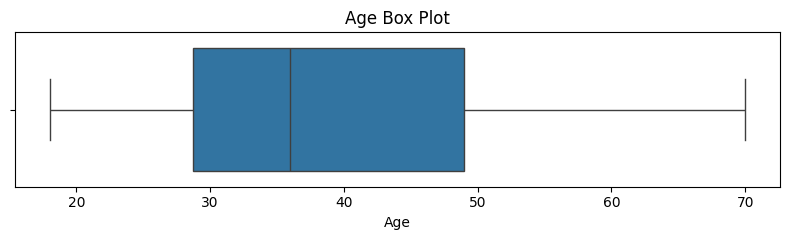

In [49]:
# Plot age box plot

plt.figure(figsize=(8, 2.5))

sns.boxplot(
    data=df,
    x="Age"
)

plt.title("Age Box Plot")
plt.xlabel("Age")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/03_age_boxplot.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

Most customers are between **25 and 40 years** of age, with the highest concentration around the early 30s. The number of customers gradually decreases as age increases, indicating that the mall primarily attracts young and middle-aged customers. The box plot shows **no significant outliers**, suggesting that the age data is well distributed and suitable for customer segmentation.

### Annual Income Distribution

The distribution of annual income is analyzed to understand the income levels of customers and identify the spread of income across the dataset.

#### Annual Income Distribution Histogram

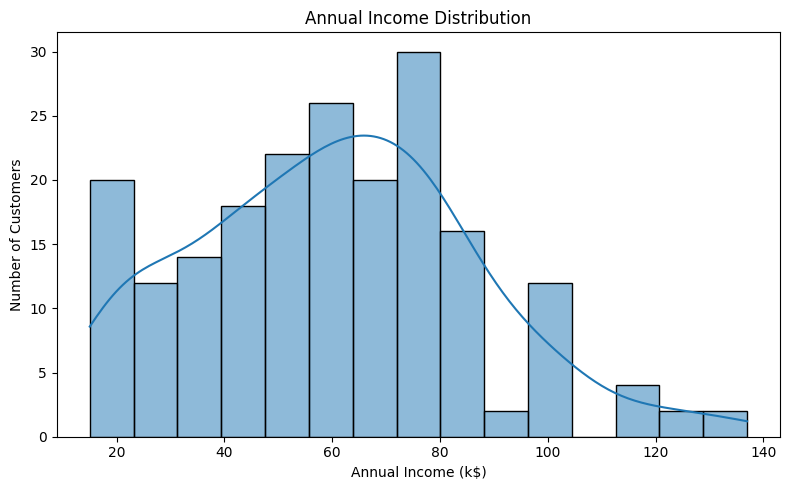

In [52]:
# Plot annual income distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Annual Income (k$)",
    bins=15,
    kde=True
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/04_annual_income_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Annual Income Distribution Box Plot

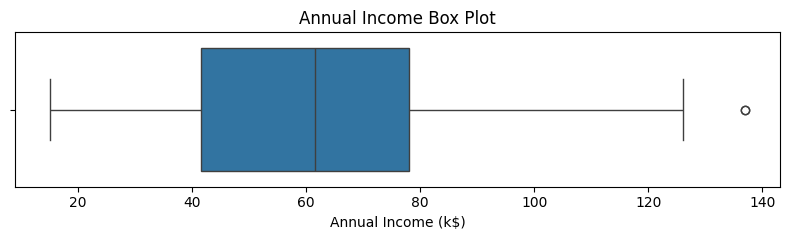

In [55]:
# Plot annual income box plot

plt.figure(figsize=(8, 2.5))

sns.boxplot(
    data=df,
    x="Annual Income (k$)"
)

plt.title("Annual Income Box Plot")
plt.xlabel("Annual Income (k$)")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/05_annual_income_boxplot.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

Most customers have an annual income between **40 thousand and 80 thousand dollars**, with the highest concentration around **60 thousand to 75 thousand dollars**. The number of customers decreases at higher income levels, indicating that relatively few customers have very high annual incomes. The box plot reveals **one potential high-income outlier**, suggesting the presence of a small number of customers with exceptionally high annual incomes.

### Spending Score Distribution

The distribution of customer spending scores is analyzed to understand customer purchasing behavior and identify how spending patterns vary across the dataset.

#### Spending Score Distribution Histogram

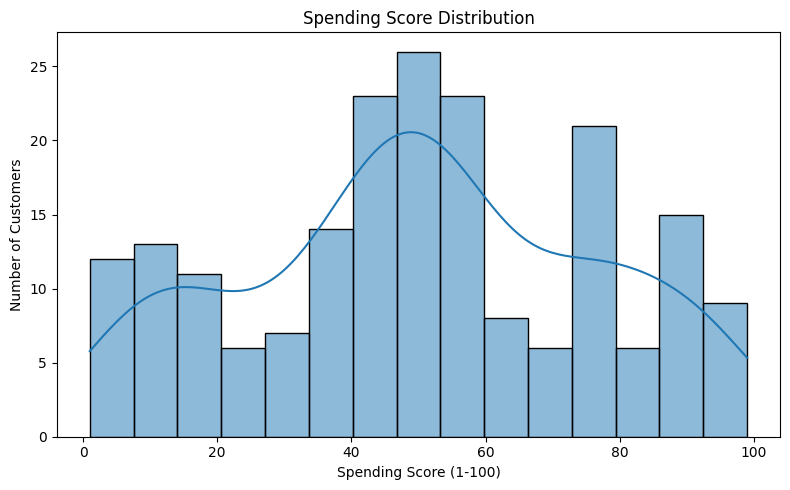

In [58]:
# Plot spending score distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Spending Score (1-100)",
    bins=15,
    kde=True
)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Number of Customers")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/06_spending_score_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Spending Score Distribution Box Plot

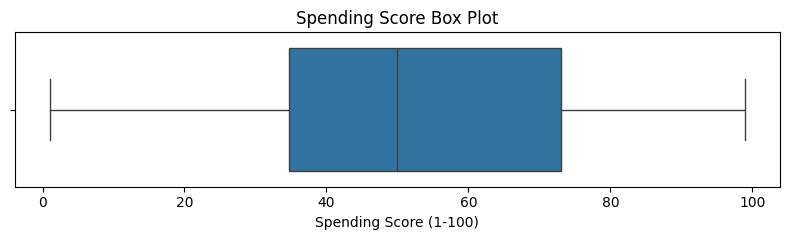

In [61]:
# Plot spending score box plot

plt.figure(figsize=(8, 2.5))

sns.boxplot(
    data=df,
    x="Spending Score (1-100)"
)

plt.title("Spending Score Box Plot")
plt.xlabel("Spending Score (1-100)")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/07_spending_score_boxplot.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

Most customers have a **moderate spending score**, with the highest concentration between **40 and 60**. The spending scores are distributed across the entire range, indicating that the dataset includes customers with both low and high spending behavior. The box plot shows **no significant outliers**, suggesting that the spending score data is well distributed and suitable for customer segmentation.

### Age vs Spending Score

The relationship between customer age and spending score is analyzed to understand how spending behavior varies across different age groups.

#### Age vs Spending Score Scatter Plot

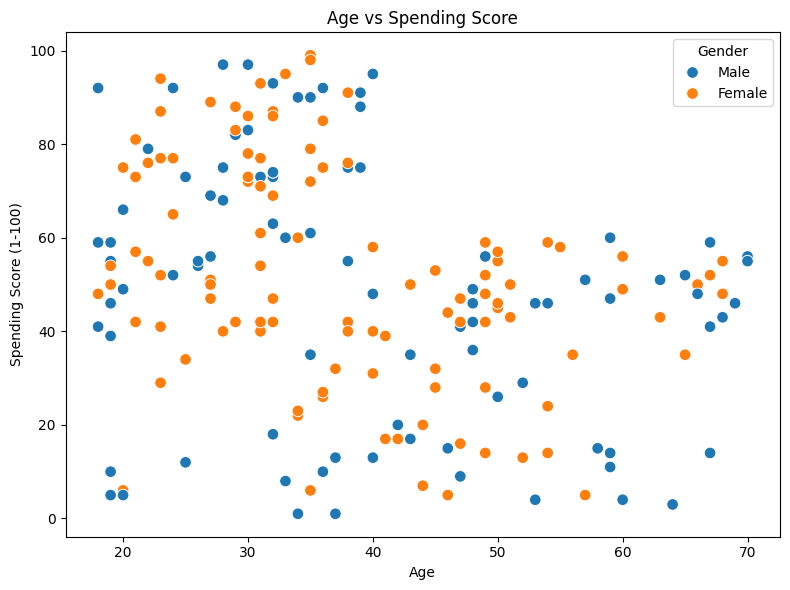

In [66]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Genre",
    s=70
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Gender")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/08_age_vs_spending_score.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()